# Sales Forecasting — Baseline
**Goal:** Predict daily `Revenue` and `COGS` for 2023-01-01 → 2024-07-01 using historical data (2012–2022).

**Strategy (simple seasonal average + trend):**
1. Compute average YoY growth rate from 2013–2022.
2. Build a "seasonal profile" — the average Revenue/COGS for each calendar day-of-year across all historical years.
3. Scale the profile by the projected year-level trend to produce predictions.

## 1 — Imports & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from xgboost import XGBRegressor, plot_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math
warnings.filterwarnings('ignore')

## 2 — Load & Inspect Data

#### 2.1 Show Tables

In [2]:
base_path = './'
files = [
    'customers.csv',
    'geography.csv',
    'inventory.csv',
    'order_items.csv',
    'orders.csv',
    'payments.csv',
    'products.csv',
    'promotions.csv',
    'returns.csv',
    'reviews.csv',
    'sales.csv',
    'shipments.csv',
    'web_traffic.csv'
]
data = {}
for file in files:
    name = file.replace('.csv', '')
    data[name] = pd.read_csv(base_path + file)
    print(f"\n{name.upper()}:")
    print(data[name].head())


CUSTOMERS:
   customer_id    zip       city signup_date  gender age_group  \
0            1  15201  Hai Phong  2021-12-30  Female     35-44   
1            2  15201  Hai Phong  2013-12-27  Female     45-54   
2            3  15201  Hai Phong  2018-07-24  Female     18-24   
3            4  15201  Hai Phong  2017-11-29    Male     35-44   
4            5  15201  Hai Phong  2022-09-23    Male       55+   

  acquisition_channel  
0        social_media  
1      email_campaign  
2      organic_search  
3            referral  
4      organic_search  

GEOGRAPHY:
     zip       city region      district
0  15201  Hai Phong   East  District #13
1  15202     Phu Ly   East  District #13
2  15203   Viet Tri   East  District #13
3  15204  Bac Giang   East  District #13
4  15205  Bac Giang   East  District #13

INVENTORY:
  snapshot_date  product_id  stock_on_hand  units_received  units_sold  \
0    2022-10-31           1              3               1           1   
1    2022-11-30           1  

#### 2.2 Load Data

In [4]:
DATA_DIR = './'

sales = pd.read_csv(DATA_DIR + 'sales.csv', parse_dates=['Date'])
test = pd.read_csv(DATA_DIR + 'sample_submission.csv', parse_dates=['Date'])
promotions = pd.read_csv(DATA_DIR + 'promotions.csv', parse_dates=['start_date', 'end_date'])

print (f"TRAIN SHAPE: {sales.shape}")
print (f"TEST SHAPE: {test.shape}")
print (f"PROMOTIONS SHAPE: {promotions.shape}")
       

TRAIN SHAPE: (3833, 3)
TEST SHAPE: (548, 3)
PROMOTIONS SHAPE: (50, 10)


#### 2.3 Data Boundaries

In [5]:
print ("DATA BOUNDERIES")
print (f'Train Period: {sales["Date"].min().date()} to {sales["Date"].max().date() }')
print (f'Test Period: {test["Date"].min().date()} to {test["Date"].max().date() }')
print ("\nBASELINE REVENUE STATS")
print (sales[['Revenue', 'COGS']].describe().round(2))

DATA BOUNDERIES
Train Period: 2012-07-04 to 2022-12-31
Test Period: 2023-01-01 to 2024-07-01

BASELINE REVENUE STATS
           Revenue         COGS
count      3833.00      3833.00
mean    4286584.03   3695134.49
std     2624840.20   2219788.77
min      279813.94    236576.31
25%     2471088.82   2150580.23
50%     3647303.90   3161112.99
75%     5350877.20   4637293.92
max    20905271.35  16535857.67


## 3 — Feature Engineering

####  3.1 kết hợp test + train


In [6]:
train = sales.copy()
train["is_test"] = 0
test_df = test[['Date']].copy()
test_df["is_test"] = 1
df = pd.concat([train, test_df], ignore_index=True)

#### 3.2 Calendar:

In [7]:
df["day_of_week"] = df["Date"].dt.dayofweek
df["day_of_month"] = df["Date"].dt.day
df["day_of_year"] = df["Date"].dt.dayofyear
df["month"] = df["Date"].dt.month
df["year"] = df["Date"].dt.year
df["is_weekend"] = np.where(df["day_of_week"] >= 5, 1, 0)
df["is_payday_window"] = np.where((df["day_of_month"] >= 25) | (df["day_of_month"] <= 5), 1, 0)
df["is_double_day"] = np.where(df["month"] == df["day_of_month"], 1, 0)
df["days_since_start"] = (df["Date"] - df["Date"].min()).dt.days

#### 3.3 Promos

In [8]:
promo_range = pd.date_range(start=df["Date"].min(), end=df["Date"].max())

daily_p = pd.DataFrame({"Date": promo_range, "is_promo": 0, "max_disc": 0.0})

for _, row in promotions.iterrows():
    mask = (daily_p["Date"] >= row["start_date"]) & (daily_p["Date"] <= row["end_date"])
    daily_p.loc[mask, "is_promo"] = 1
    if row["promo_type"] == "percentage":
        daily_p.loc[mask, "max_disc"] = np.maximum(daily_p.loc[mask, "max_disc"], row["discount_value"])

df = df.merge(daily_p, on="Date", how="left").fillna(0)

## 4 — Build Seasonal Profile

Average Revenue / COGS by **(month, day)** across all available years. This captures seasonal patterns while smoothing out year-specific noise.

In [9]:
#Tách dữ liệu train và test sau khi feature engineering
train_df = df[df["is_test"] == 0].copy()  
test_df = df[df["is_test"] == 1].copy()

# Normalise each year so seasonal profile is scale-free
train_df["target_rev"] = np.log1p(train_df["Revenue"])
train_df["target_cogs"] = np.log1p(train_df["COGS"])
# Average normalised value for each (month, day)
features = ["day_of_week", "day_of_month", "month", "is_weekend", "is_payday_window", "is_double_day", "is_promo", "max_disc"]

X_train = train_df[features]
X_test = test_df[features]

## 5 — Predict Test Period

In [10]:

best_params = {
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'tree_method': 'hist',
    'device': 'cuda'
}

print ("Training XGBoost for Revenue...")
model_rev = XGBRegressor(**best_params)
model_rev.fit(X_train, train_df["target_rev"])

model_cogs = XGBRegressor(**best_params)
model_cogs.fit(X_train, train_df["target_cogs"])

test_df["Revenue_pred"] = np.expm1(model_rev.predict(X_test))
test_df["COGS_pred"] = np.expm1(model_cogs.predict(X_test))

Training XGBoost for Revenue...


## 6 — Evaluate on Training Tail (2021–2022)

Quick sanity-check: apply the same method on the last 2 years of training data and measure MAPE.

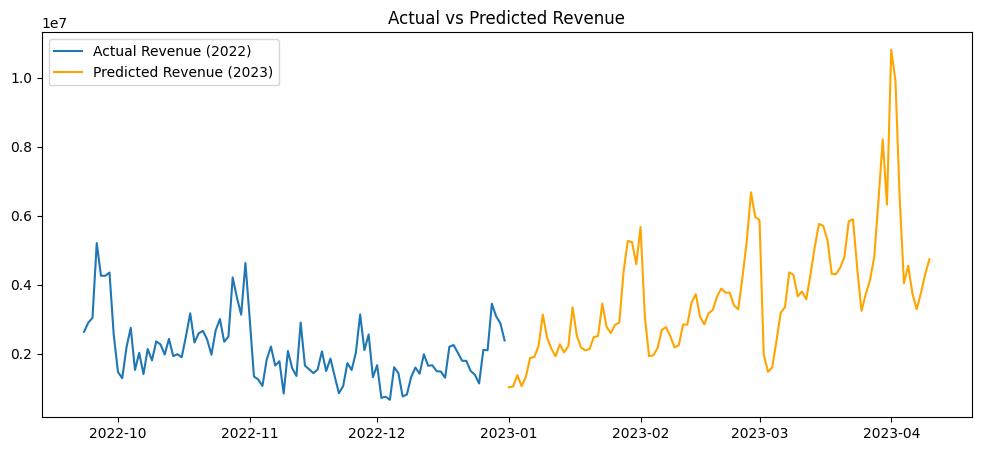

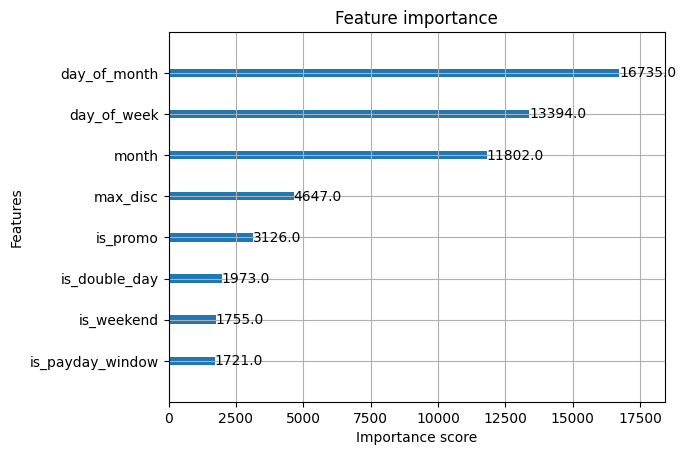

In [11]:
plt.figure(figsize=(12, 5))

plt.plot(
    train_df["Date"].tail(100), 
    train_df["Revenue"].tail(100),
    label="Actual Revenue (2022)"
)

plt.plot(
    test_df["Date"].head(100),
    test_df["Revenue_pred"].head(100),
    label="Predicted Revenue (2023)",
    color='orange'
)

plt.title("Actual vs Predicted Revenue")
plt.legend()
plt.show()

plot_importance(model_rev, max_num_features=10)
plt.show()

## 7 — Export Submission

In [12]:
submission = test[['Date', 'Revenue', 'COGS']].copy()
submission["Date"] = submission['Date'].dt.strftime('%Y-%m-%d')
submission.to_csv("submission.csv", index=False)
print("Saved 'submission.csv' with baseline predictions.")



Saved 'submission.csv' with baseline predictions.
